In [1]:
import pandas as pd
df = pd.read_csv("D:\Data\CSV Data\cat_acidentes.csv")

In [5]:
df

,data_extracao;predial1;queda_arr;data;feridos;feridos_gr;mortes;morte_post;fatais;auto;taxi;lotacao;onibus_urb;onibus_met;onibus_int;caminhao;moto;carroca;bicicleta;outro;cont_vit;ups;patinete;idacidente;longitude;latitude;log1;log2;tipo_acid;dia_sem;hora;noite_dia;regiao;consorcio
0,2025-09-01 01:33:25;0;0.0;2020-10-17 00:00:00;...
1,2025-09-01 01:33:25;598;0.0;2020-01-01 00:00:0...
2,2025-09-01 01:33:25;1271;0.0;2020-01-01 00:00:...
3,2025-09-01 01:33:25;1901;0.0;2020-01-02 00:00:...
4,2025-09-01 01:33:25;3302;0.0;2020-01-02 00:00:...
...,...
75171,2025-09-01 01:33:25;680.0;0.0;2025-07-03 00:00...
75172,2025-09-01 01:33:25;421.0;0.0;2025-07-03 00:00...
75173,2025-09-01 01:33:25;1024.0;0.0;2025-07-07 00:0...
75174,2025-09-01 01:33:25;1039.0;0.0;2025-07-07 00:0...


In [6]:
import pandas as pd
df = pd.read_csv("D:\Data\CSV Data\cat_acidentes.csv", sep = ';')

In [7]:
df

,data_extracao,predial1,queda_arr,data,feridos,feridos_gr,mortes,morte_post,fatais,auto,...,longitude,latitude,log1,log2,tipo_acid,dia_sem,hora,noite_dia,regiao,consorcio
0,2025-09-01 01:33:25,0.0,0.0,2020-10-17 00:00:00,1,0,0,0,0,3,...,0.000000,0.000000,R MARCOS MOREIRA,R GASTON ENGLERT,ABALROAMENTO,SÁBADO,19:00:00.0000000,NOITE,NORTE,NaN
1,2025-09-01 01:33:25,598.0,0.0,2020-01-01 00:00:00,1,0,0,0,0,0,...,NaN,NaN,AV BENTO GONCALVES,NaN,ABALROAMENTO,QUARTA-FEIRA,03:00:00.0000000,NOITE,LESTE,NaN
2,2025-09-01 01:33:25,1271.0,0.0,2020-01-01 00:00:00,1,1,0,0,0,1,...,NaN,NaN,AV INDEPENDENCIA,NaN,ATROPELAMENTO,QUARTA-FEIRA,23:00:00.0000000,NOITE,LESTE,NaN
3,2025-09-01 01:33:25,1901.0,0.0,2020-01-02 00:00:00,2,0,0,0,0,0,...,NaN,NaN,AV EDUARDO PRADO,NaN,ATROPELAMENTO,QUINTA-FEIRA,00:05:00.0000000,NOITE,SUL,NaN
4,2025-09-01 01:33:25,3302.0,0.0,2020-01-02 00:00:00,1,0,0,0,0,1,...,-51.211535,-30.081535,AV TERESOPOLIS,NaN,ABALROAMENTO,QUINTA-FEIRA,09:00:00.0000000,DIA,SUL,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75171,2025-09-01 01:33:25,680.0,0.0,2025-07-03 00:00:00,0,0,0,0,0,2,...,-51.213184,-30.049725,AV AZENHA,NaN,COLISÃO,QUINTA-FEIRA,16:30:00.0000000,DIA,LESTE,NaN
75172,2025-09-01 01:33:25,421.0,0.0,2025-07-03 00:00:00,0,0,0,0,0,1,...,-51.204159,-30.033800,R CABRAL,R MARIANTE,COLISÃO,QUINTA-FEIRA,18:15:00.0000000,NOITE,LESTE,NaN
75173,2025-09-01 01:33:25,1024.0,0.0,2025-07-07 00:00:00,0,0,0,0,0,1,...,-51.248341,-30.099139,AV WENCESLAU ESCOBAR,NaN,COLISÃO,SEGUNDA-FEIRA,09:10:00.0000000,DIA,SUL,NaN
75174,2025-09-01 01:33:25,1039.0,0.0,2025-07-07 00:00:00,0,0,0,0,0,1,...,-51.230281,-30.093377,R SANTA FLORA,NaN,COLISÃO,SEGUNDA-FEIRA,13:35:00.0000000,DIA,SUL,NaN


## Data Wrangling

### Apagar valores faltantes NaN

In [16]:
df = df.dropna(subset=['latitude', 'longitude'], how='any')

### Trazer um mapa de calor para ver a distribuição dos acidentes

In [9]:
!pip install folium


   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [17]:
import folium
from folium.plugins import HeatMap

mapa = folium.Map(location=[-30.1, -51.15], zoom_start=11)
coordenadas = list(zip(df.latitude, df.longitude))
mapa_calor = HeatMap(coordenadas)
mapa.add_child(mapa_calor)

mapa

[Interactive map removed from download - see tomane-portfolio.com]

### Adicionar parâmetros no Mapa

In [18]:
mapa_calor = HeatMap(coordenadas, radius=9, blur=10)
mapa.add_child(mapa_calor)

mapa

[Interactive map removed from download - see tomane-portfolio.com]

### Criando clusters das regioes no Mapa

In [19]:
import folium
from folium.plugins import MarkerCluster

mapa = folium.Map(location=[-30.1, -51.15], zoom_start=11)
coordenadas = list(zip(df.latitude, df.longitude))
mapa_cluster = MarkerCluster(coordenadas)
mapa.add_child(mapa_cluster)

mapa

[Interactive map removed from download - see tomane-portfolio.com]

## Data Wrangling 2

### Conversão de object de data para uma data real

In [21]:
df['data'] = pd.to_datetime(df['data'], errors = 'coerce')
df_ano = df['data'].dt.year.value_counts()
df_ano

C:\Users\Tomane Asus\AppData\Local\Temp\ipykernel_8792\2528026447.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['data'] = pd.to_datetime(df['data'], errors = 'coerce')


data
2023    14575
2024    13711
2022    13327
2021    11701
2025     8369
2020     2897
Name: count, dtype: int64

### Frequência dos acidentes ao longo dos anos num grafico

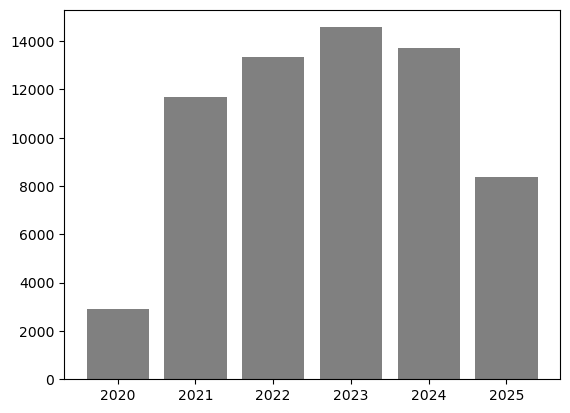

In [30]:
import matplotlib.pyplot as plt

plt.bar(df_ano.index, df_ano.values, color = 'gray')
plt.show()

#### Usando gradientes de cores pra melhor visualizar

In [31]:
df_ano/df_ano.max()

data
2023    1.000000
2024    0.940720
2022    0.914374
2021    0.802813
2025    0.574202
2020    0.198765
Name: count, dtype: float64

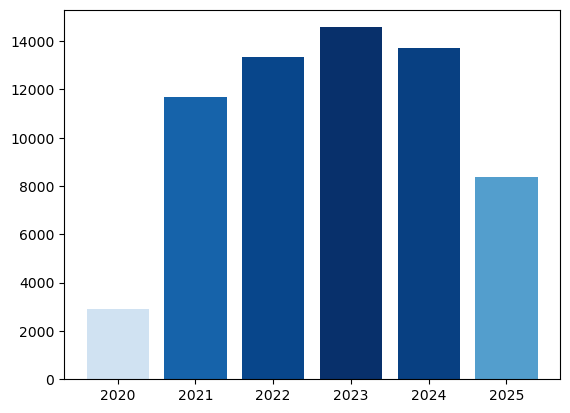

In [35]:
gradiente = df_ano/df_ano.max()
cores = plt.cm.Blues(gradiente)

plt.bar(df_ano.index, df_ano.values, color = cores)
plt.show()